# Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Load the Dataset

In [3]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

VALID_DIR = r"C:\Plant Disease Detection\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\valid"

# CNN
cnn_test_generator = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    VALID_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

# ResNet50
resnet_test_generator = ImageDataGenerator(
    preprocessing_function=resnet_preprocess
).flow_from_directory(
    VALID_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

# EfficientNet
efficientnet_test_generator = ImageDataGenerator(
    preprocessing_function=efficientnet_preprocess
).flow_from_directory(
    VALID_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

# MobileNet (keep same as training)
mobilenet_test_generator = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    VALID_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

print(cnn_test_generator.class_indices)
print("Classes:", cnn_test_generator.num_classes)

Found 17572 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___

# Load all Models

In [4]:
from tensorflow.keras.models import load_model

cnn_model = load_model("cnn_model.keras")

resnet_model = load_model("resnet50_best.keras")

efficientnet_model = load_model("efficientnet_final.keras")

mobilenet_model = load_model("mobilenet_final.keras")

print("All Models Loaded Successfully!")

All Models Loaded Successfully!


# Evaluation function

In [5]:
def evaluate_model(model, test_generator, model_name):

    print("="*60)
    print(model_name)
    print("="*60)

    predictions = model.predict(test_generator)

    predicted_classes = np.argmax(predictions, axis=1)

    true_classes = test_generator.classes

    accuracy = accuracy_score(
        true_classes,
        predicted_classes
    )

    precision = precision_score(
        true_classes,
        predicted_classes,
        average="weighted"
    )

    recall = recall_score(
        true_classes,
        predicted_classes,
        average="weighted"
    )

    f1 = f1_score(
        true_classes,
        predicted_classes,
        average="weighted"
    )

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report\n")

    print(classification_report(
        true_classes,
        predicted_classes,
        target_names=cnn_test_generator.class_indices.keys()
    ))

    cm = confusion_matrix(
        true_classes,
        predicted_classes
    )

    plt.figure(figsize=(12,10))

    sns.heatmap(
        cm,
        cmap="Blues"
    )

    plt.title(model_name + " Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    return accuracy

# Evaluate CNN

CNN
550/550 ━━━━━━━━━━━━━━━━━━━━ 149s 268ms/step
Accuracy : 0.9290
Precision: 0.9309
Recall   : 0.9290
F1 Score : 0.9282

Classification Report

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.88      0.92       504
                                 Apple___Black_rot       0.97      0.97      0.97       497
                          Apple___Cedar_apple_rust       0.94      0.97      0.96       440
                                   Apple___healthy       0.92      0.95      0.93       502
                               Blueberry___healthy       0.98      0.95      0.97       454
          Cherry_(including_sour)___Powdery_mildew       0.95      0.97      0.96       421
                 Cherry_(including_sour)___healthy       0.87      1.00      0.93       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.85      0.89      0.87       410
                       Cor

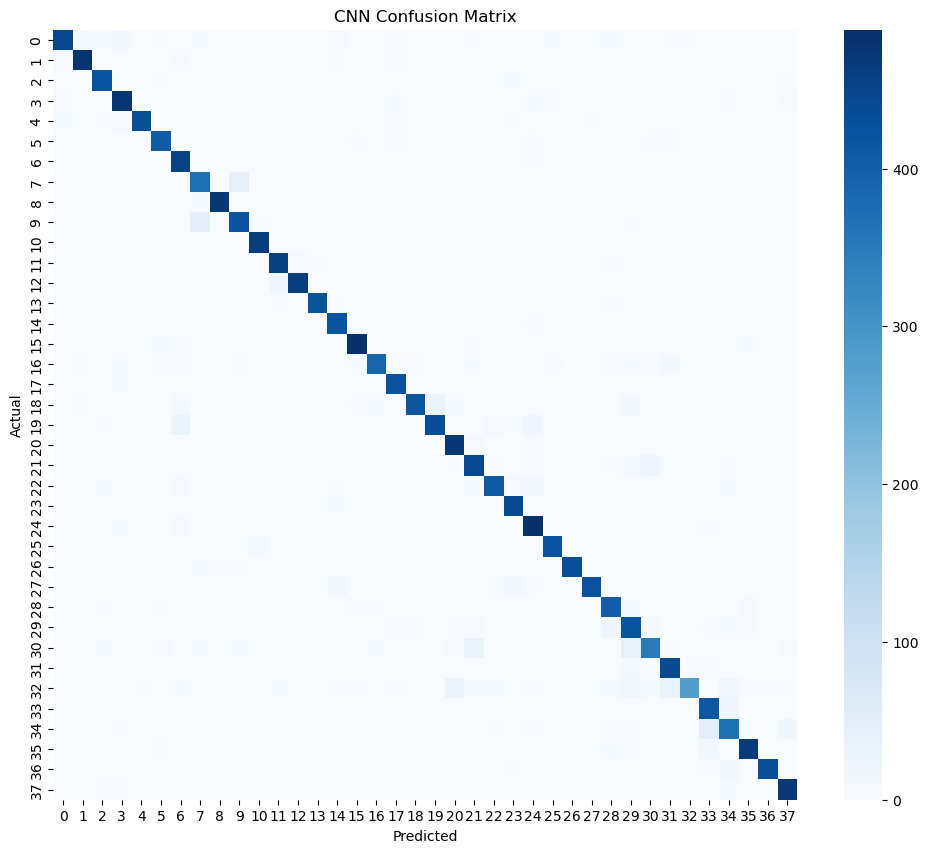

In [6]:
cnn_accuracy = evaluate_model(
    cnn_model,
    cnn_test_generator,
    "CNN"
)

# Evaluate ResNet50

ResNet50
550/550 ━━━━━━━━━━━━━━━━━━━━ 833s 2s/step
Accuracy : 0.9747
Precision: 0.9755
Recall   : 0.9747
F1 Score : 0.9748

Classification Report

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.98      0.98       504
                                 Apple___Black_rot       0.98      0.99      0.99       497
                          Apple___Cedar_apple_rust       1.00      1.00      1.00       440
                                   Apple___healthy       0.98      0.99      0.99       502
                               Blueberry___healthy       0.98      1.00      0.99       454
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      0.99       421
                 Cherry_(including_sour)___healthy       0.99      1.00      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.94      0.93       410
                       C

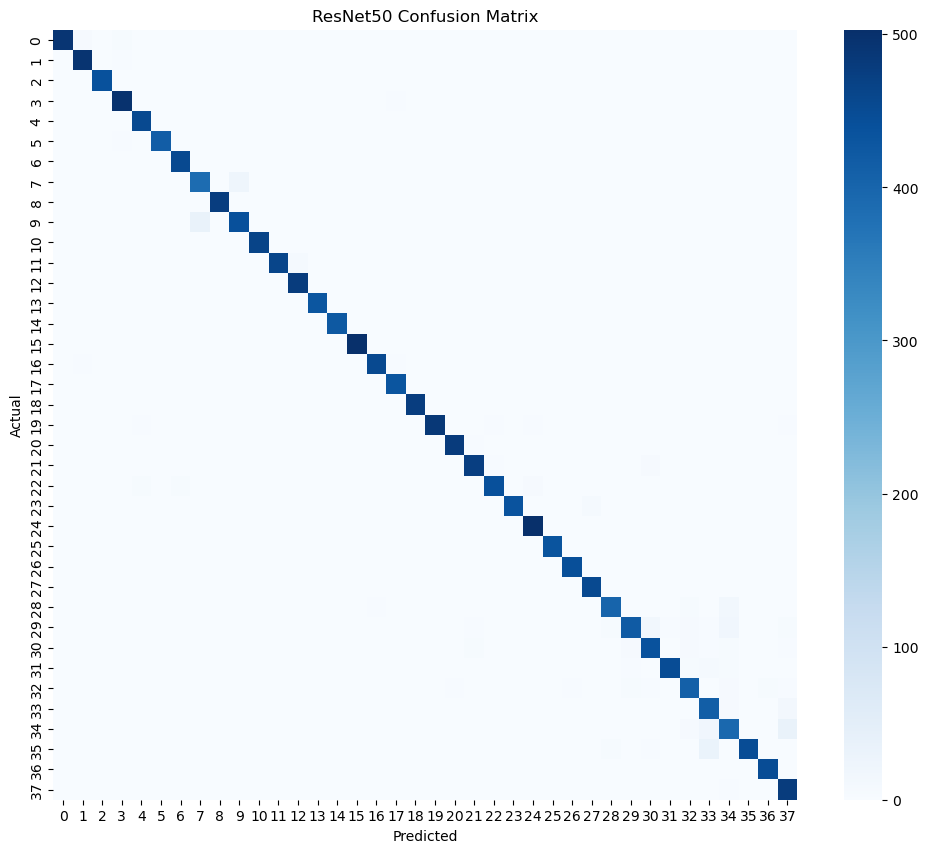

In [9]:
resnet_accuracy = evaluate_model(
    resnet_model,
    resnet_test_generator,
    "ResNet50"
)

# Evaluate MobileNetV2

MobileNetV2
550/550 ━━━━━━━━━━━━━━━━━━━━ 5856s 11s/step
Accuracy : 0.9244
Precision: 0.9284
Recall   : 0.9244
F1 Score : 0.9235

Classification Report

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.93      0.96      0.95       504
                                 Apple___Black_rot       0.95      0.99      0.97       497
                          Apple___Cedar_apple_rust       0.99      0.98      0.98       440
                                   Apple___healthy       0.98      0.97      0.97       502
                               Blueberry___healthy       0.97      0.97      0.97       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.98      0.98       421
                 Cherry_(including_sour)___healthy       0.95      0.99      0.97       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.98      0.80      0.88       410
                   

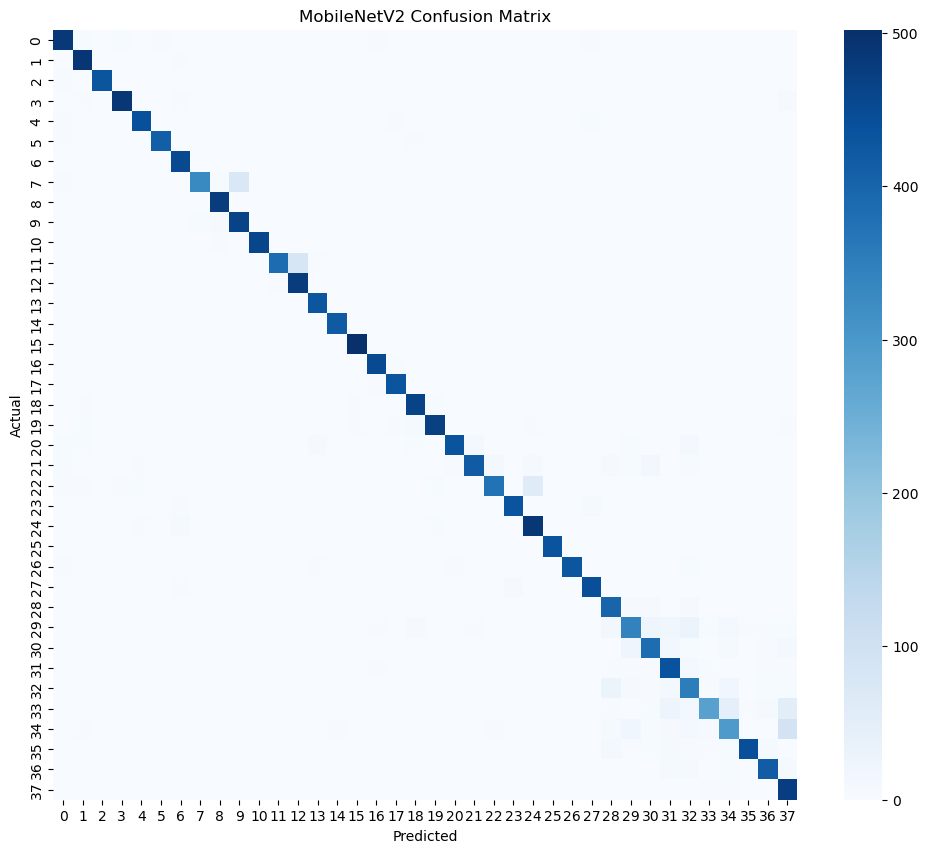

In [11]:
mobilenet_accuracy = evaluate_model(
    mobilenet_model,
    mobilenet_test_generator,
    "MobileNetV2"
)

# Evaluate EfficientNetB0

EfficientNetB0
550/550 ━━━━━━━━━━━━━━━━━━━━ 439s 785ms/step
Accuracy : 0.9645
Precision: 0.9667
Recall   : 0.9645
F1 Score : 0.9649

Classification Report

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.96      0.97       504
                                 Apple___Black_rot       0.98      1.00      0.99       497
                          Apple___Cedar_apple_rust       1.00      0.98      0.99       440
                                   Apple___healthy       0.98      0.99      0.98       502
                               Blueberry___healthy       0.99      1.00      1.00       454
          Cherry_(including_sour)___Powdery_mildew       1.00      0.98      0.99       421
                 Cherry_(including_sour)___healthy       0.99      1.00      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.95      0.92      0.94       410
               

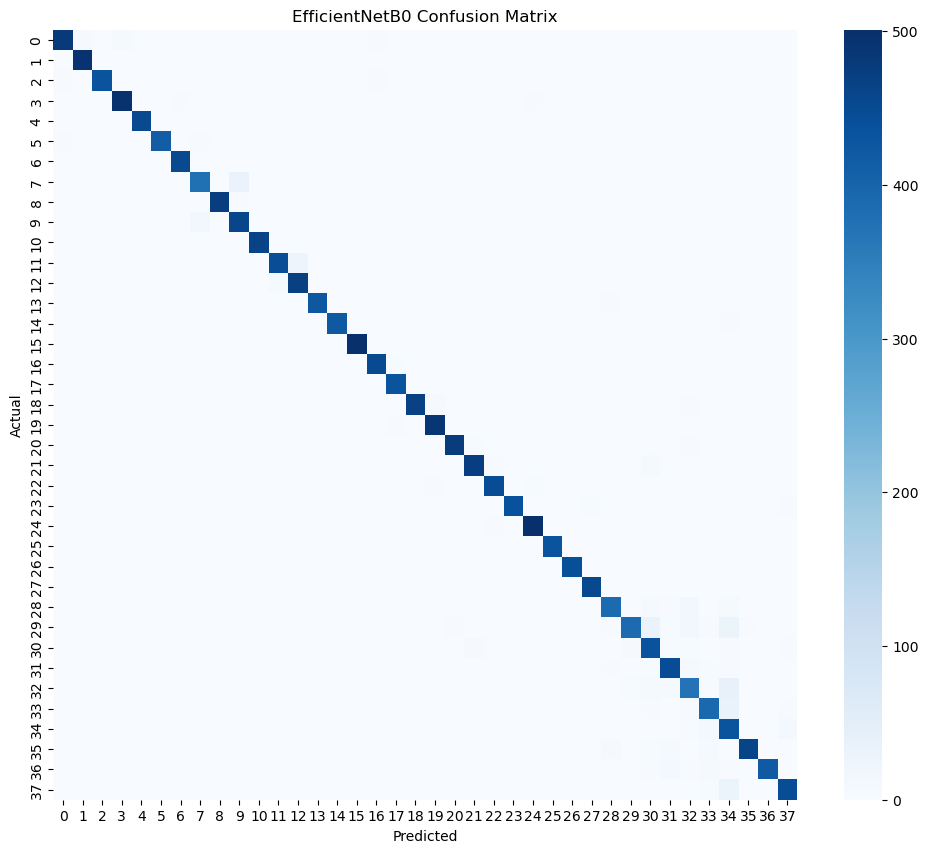

In [8]:
efficientnet_accuracy = evaluate_model(
    efficientnet_model,
    efficientnet_test_generator,
    "EfficientNetB0"
)

# Compare All Models

In [12]:
import pandas as pd
results = pd.DataFrame({

    "Model":[
        "CNN",
        "ResNet50",
        "EfficientNetB0",
        "MobileNetV2"
    ],

    "Accuracy":[
        cnn_accuracy,
        resnet_accuracy,
        efficientnet_accuracy,
        mobilenet_accuracy
    ]

})

results

,Model,Accuracy
0,CNN,0.929035
1,ResNet50,0.974733
2,EfficientNetB0,0.964489
3,MobileNetV2,0.924368


# Accuracy Comparison Graph

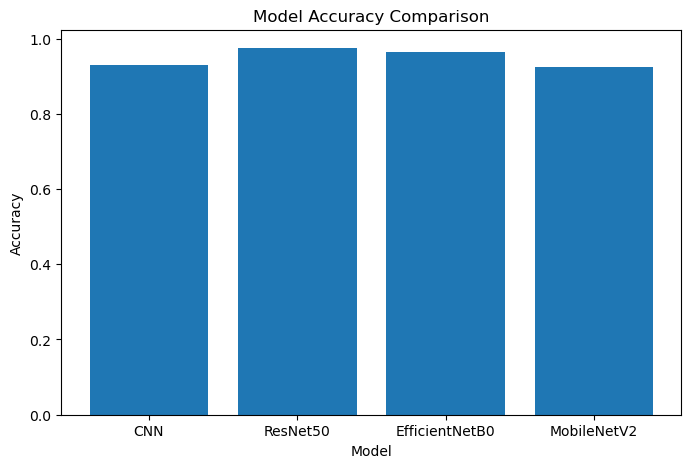

In [13]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.xlabel("Model")

plt.ylabel("Accuracy")

plt.show()

# Save Results

In [14]:
results.to_csv("model_comparison.csv", index=False)

print("Results Saved Successfully!")

Results Saved Successfully!
